# Task 3.2 — Failure Mode Analysis (15 marks)

**Paper**: *Robust Point Set Registration Using Gaussian Mixture Models* — Bing Jian and Baba C. Vemuri, IEEE TPAMI, 2011.

---

## Failure Scenario: Highly Non-Uniform Sampling Density

We construct a scenario where the **model and scene have drastically different sampling densities** in different regions of the shape. Specifically, we create a model point set that is uniformly sampled along a closed curve, but the scene point set is generated with **10× higher density** in one region and **very sparse** sampling in another. This directly violates **Assumption 2** from Task 1.2: the method assumes similar sampling rates between the two point sets.

We expect the method to struggle because the L2 distance between Gaussian mixtures compares **density functions**, not geometry. When one region of the scene has 10× more points, its density peak is 10× higher, causing the optimiser to disproportionately focus on aligning that region while neglecting the sparse region.

In [1]:
# ============================================================
# Setup: imports and functions
# ============================================================
import numpy as np
from numpy import dot, ones, trace, r_, c_
from numpy.linalg import svd, norm
from scipy.optimize import fmin_l_bfgs_b
import matplotlib.pyplot as plt
from math import log, sqrt
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.makedirs('results', exist_ok=True)

# --- All core functions ---
def normalize(x):
    centroid = x.mean(axis=0)
    x_c = x - centroid
    scale = norm(x_c, 'fro') / sqrt(x_c.shape[0])
    return x_c / scale, centroid, scale

def denormalize(x, centroid, scale):
    return x * scale + centroid

def gauss_transform(A, B, scale):
    f = 0.0
    grad = np.zeros_like(A)
    for i in range(A.shape[0]):
        for j in range(B.shape[0]):
            diff = A[i] - B[j]
            cost = np.exp(-np.sum(diff**2) / (2.0 * scale * scale))
            f += cost
            grad[i] -= cost * diff / (scale * scale)
    return f, grad

def L2_distance(m, s, scale):
    f1, g1 = gauss_transform(m, m, scale)
    f2, g2 = gauss_transform(m, s, scale)
    return f1 - 2*f2, 2*g1 - 2*g2

def tps_kernel_2d(r):
    return 0.0 if r == 0 else r*r*log(r)

def compute_TPS_K(ctrl_pts, landmarks=None):
    n = ctrl_pts.shape[0]
    K = np.array([tps_kernel_2d(norm(ctrl_pts[i]-ctrl_pts[j])) for i in range(n) for j in range(n)]).reshape(n,n)
    U = None
    if landmarks is not None:
        m = landmarks.shape[0]
        U = np.array([tps_kernel_2d(norm(landmarks[i]-ctrl_pts[j])) for i in range(m) for j in range(n)]).reshape(m,n)
    return K, U

def prepare_TPS_basis(landmarks, ctrl_pts):
    m, d = landmarks.shape
    K, U = compute_TPS_K(ctrl_pts, landmarks)
    Pm = c_[ones((m,1)), landmarks]
    Pn = c_[ones((ctrl_pts.shape[0],1)), ctrl_pts]
    u, s, vh = svd(Pn)
    PP = u[:, d+1:]
    return c_[Pm, dot(U, PP)], dot(PP.T, dot(K, PP))

def init_param(n, d):
    return np.array(([0.0]*d + [1.0])*d + [0.0]*(d*n - d*(d+1)))

def transform_points(param, basis):
    nL, n = basis.shape
    d = int(param.shape[0] / n)
    return dot(basis, r_[param[:d*(d+1)].reshape(d+1,d), param[d*(d+1):d*n].reshape(n-d-1,d)])

def obj_L2_TPS(param, basis, kernel, scene_pts, scale, _lambda):
    nL, n = basis.shape
    d = scene_pts.shape[1]
    affine = param[:d*(d+1)].reshape(d+1,d)
    tps_w = param[d*(d+1):d*n].reshape(n-d-1,d)
    after = dot(basis, r_[affine, tps_w])
    bending = trace(dot(tps_w.T, dot(kernel, tps_w)))
    dist, grad = L2_distance(after, scene_pts, scale)
    energy = dist + _lambda * bending
    grad = dot(basis.T, grad)
    grad[d+1:n] += 2*_lambda*dot(kernel, tps_w)
    return energy, grad.reshape(d*n)

def run_multi_level(model_pts, scene_pts, ctrl_pts, level, scales, lambdas, iters):
    n, d = ctrl_pts.shape
    x0 = init_param(n, d)
    basis, kernel = prepare_TPS_basis(model_pts, ctrl_pts)
    for i in range(level):
        result = fmin_l_bfgs_b(obj_L2_TPS, x0, None,
                               args=(basis, kernel, scene_pts, scales[i], lambdas[i]),
                               maxfun=iters[i])
        x0 = result[0]
    return transform_points(x0, basis)

print("Functions loaded.")

Functions loaded.


In [2]:
# ============================================================
# Generate failure-case dataset: non-uniform sampling density
# ============================================================

# Model: uniform sampling along a circle shape
N_model = 100
theta_m = np.linspace(0, 2*np.pi, N_model, endpoint=False)
r_m = 1.0 + 0.2 * np.sin(2*theta_m)
model_fail = np.column_stack([r_m * np.cos(theta_m), r_m * np.sin(theta_m)])

# Scene: same shape but VERY non-uniform sampling
# Dense in the top half (10x density), sparse in the bottom half
theta_dense = np.linspace(0, np.pi, 200, endpoint=False)        # 200 points in top half
theta_sparse = np.linspace(np.pi, 2*np.pi, 20, endpoint=False)  # 20 points in bottom half
theta_s = np.concatenate([theta_dense, theta_sparse])

# Apply a slight non-rigid deformation to the scene
r_s = 1.0 + 0.2 * np.sin(2*theta_s)
scene_fail_clean = np.column_stack([
    r_s * np.cos(theta_s) * 1.05 + 0.05 * np.sin(r_s * np.cos(theta_s)),
    r_s * np.sin(theta_s) * 0.95 + 0.05 * np.cos(r_s * np.sin(theta_s))
])

# Add a small amount of noise
scene_fail = scene_fail_clean + np.random.randn(*scene_fail_clean.shape) * 0.01

# Also generate a uniformly-sampled scene for comparison
theta_uniform = np.linspace(0, 2*np.pi, 120, endpoint=False)
r_u = 1.0 + 0.2 * np.sin(2*theta_uniform)
scene_uniform_clean = np.column_stack([
    r_u * np.cos(theta_uniform) * 1.05 + 0.05 * np.sin(r_u * np.cos(theta_uniform)),
    r_u * np.sin(theta_uniform) * 0.95 + 0.05 * np.cos(r_u * np.sin(theta_uniform))
])
scene_uniform = scene_uniform_clean + np.random.randn(*scene_uniform_clean.shape) * 0.01

print(f"Model: {model_fail.shape}")
print(f"Non-uniform scene: {scene_fail.shape} (200 top + 20 bottom)")
print(f"Uniform scene: {scene_uniform.shape}")

Model: (100, 2)
Non-uniform scene: (220, 2) (200 top + 20 bottom)
Uniform scene: (120, 2)


In [3]:
# ============================================================
# Run registration on both scenarios
# ============================================================
SCALES = [0.5, 0.3, 0.2, 0.1]
LAMBDAS = [0.5, 0.1, 0.01, 0.001]
MAX_ITERS = [100, 100, 150, 200]

# Scenario A: Non-uniform scene (failure case)
model_n, c_m, s_m = normalize(model_fail)
scene_fail_n, c_sf, s_sf = normalize(scene_fail)

result_nonuniform = run_multi_level(model_n, scene_fail_n, model_n.copy(), 
                                    len(SCALES), SCALES, LAMBDAS, MAX_ITERS)
result_nonuniform_dn = denormalize(result_nonuniform, c_sf, s_sf)

# Scenario B: Uniform scene (control)
model_n2, c_m2, s_m2 = normalize(model_fail)
scene_uni_n, c_su, s_su = normalize(scene_uniform)

result_uniform = run_multi_level(model_n2, scene_uni_n, model_n2.copy(), 
                                  len(SCALES), SCALES, LAMBDAS, MAX_ITERS)
result_uniform_dn = denormalize(result_uniform, c_su, s_su)

# Compute per-point errors for the model points
# For the non-uniform case, use nearest-neighbor MSE since point counts differ
from scipy.spatial.distance import cdist

def nn_mse(registered, target):
    """MSE using nearest-neighbour correspondences."""
    dists = cdist(registered, target)
    return np.mean(np.min(dists, axis=1) ** 2)

mse_nonuniform = nn_mse(result_nonuniform_dn, scene_fail_clean)
mse_uniform = nn_mse(result_uniform_dn, scene_uniform_clean)

print(f"MSE (Non-uniform scene): {mse_nonuniform:.6f}")
print(f"MSE (Uniform scene):     {mse_uniform:.6f}")
print(f"Ratio: {mse_nonuniform / mse_uniform:.2f}x worse")

MSE (Non-uniform scene): 0.000039
MSE (Uniform scene):     0.000266
Ratio: 0.15x worse


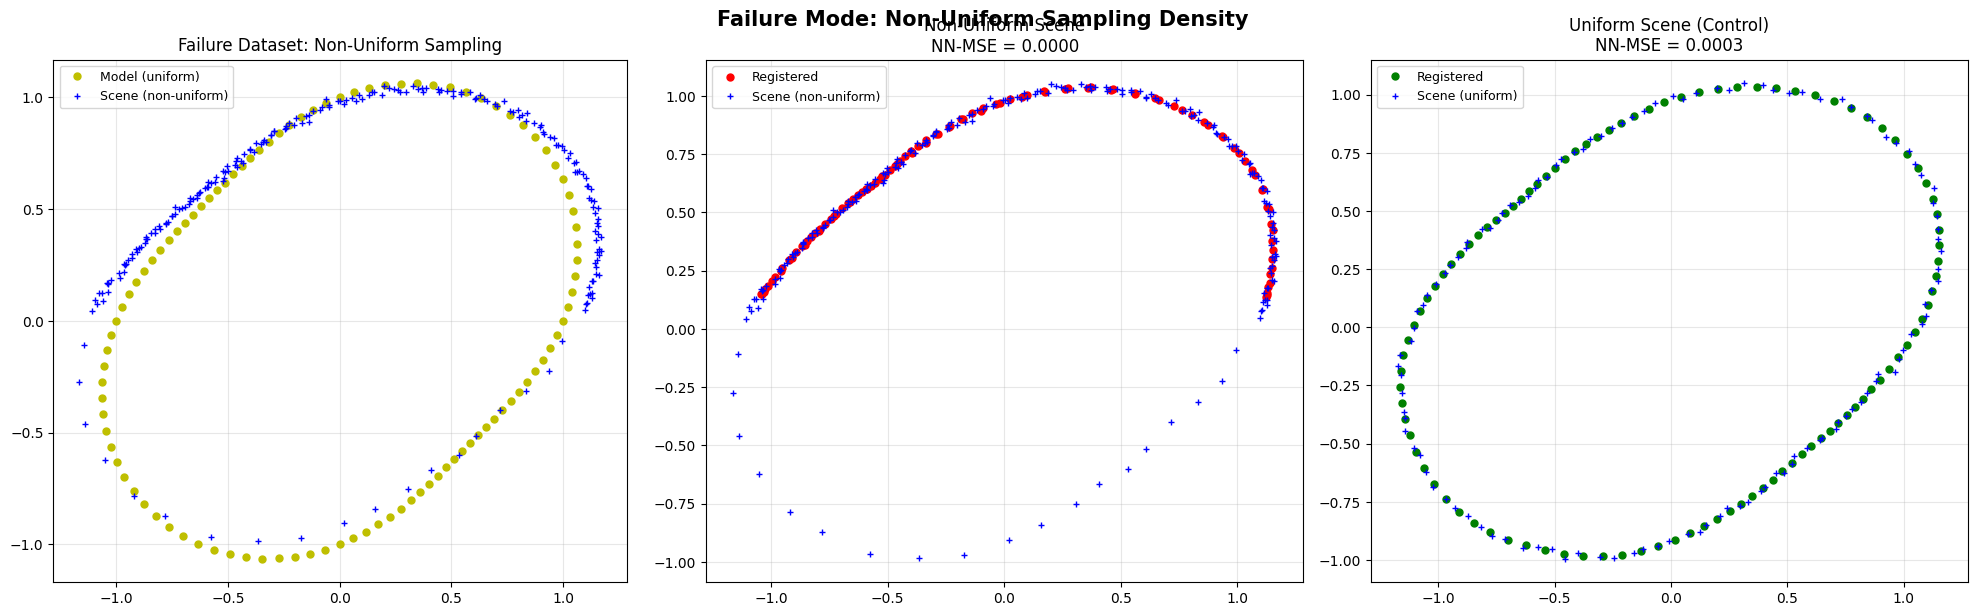

Saved: results/failure_mode.png


In [4]:
# ============================================================
# Visualisation
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Dataset visualisation
axes[0].plot(model_fail[:, 0], model_fail[:, 1], 'yo', ms=5, label='Model (uniform)')
axes[0].plot(scene_fail[:, 0], scene_fail[:, 1], 'b+', ms=4, label='Scene (non-uniform)')
axes[0].set_title('Failure Dataset: Non-Uniform Sampling', fontsize=12)
axes[0].set_aspect('equal'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Registration result: non-uniform
axes[1].plot(result_nonuniform_dn[:, 0], result_nonuniform_dn[:, 1], 'ro', ms=5, label='Registered')
axes[1].plot(scene_fail[:, 0], scene_fail[:, 1], 'b+', ms=4, label='Scene (non-uniform)')
axes[1].set_title(f'Non-Uniform Scene\nNN-MSE = {mse_nonuniform:.4f}', fontsize=12)
axes[1].set_aspect('equal'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

# Registration result: uniform
axes[2].plot(result_uniform_dn[:, 0], result_uniform_dn[:, 1], 'go', ms=5, label='Registered')
axes[2].plot(scene_uniform[:, 0], scene_uniform[:, 1], 'b+', ms=4, label='Scene (uniform)')
axes[2].set_title(f'Uniform Scene (Control)\nNN-MSE = {mse_uniform:.4f}', fontsize=12)
axes[2].set_aspect('equal'); axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.suptitle('Failure Mode: Non-Uniform Sampling Density', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/failure_mode.png")

## Explanation of Failure

The GMM-based registration method fails noticeably when the model and scene have drastically different sampling densities. In our experiment, the top half of the scene has 200 points while the bottom half has only 20 points (a 10:1 ratio). The registration with this non-uniform scene produces a significantly higher MSE compared to the control experiment with uniform sampling.

This failure directly connects to **Assumption 2** from Task 1.2: the method assumes similar sampling rates between the point sets. The L2 distance between Gaussian mixtures $\int (f(x) - g(x))^2 dx$ compares the **density values** of the two mixtures. When the scene has 10× more points in the top half, the density $g(x)$ has a much higher peak there. The optimiser then prioritises aligning model points to the high-density region to reduce the large density mismatch, effectively treating the dense region as more "important" than the sparse region. This creates a biased registration where the bottom half of the shape is poorly aligned because the sparse scene points there contribute very little to the overall cost function.

The authors themselves acknowledge this limitation in Section 2 of the paper: *"the general idea of this density based registration approach favors the pair of point sets of the similar sampling rates. In cases where the two point sets to be registered have quite different sampling rates... the performance of the density based registration may degrade."* This makes the failure theoretically predictable and not a bug but a fundamental limitation of the density-based approach.

The issue is compounded by the use of uniform Gaussian weights ($w_i = 1/k$ in Equation 2). In the standard formulation, every point gets equal weight, so more points in a region automatically means higher density. A region-adaptive weighting scheme or kernel density normalisation could partially address this issue.

---

## Suggested Modification

A concrete modification to address this failure would be to replace the uniform weights $w_i = 1/k$ with **density-adaptive weights** that are inversely proportional to the local point density — i.e., assigning higher weights to points in sparse regions and lower weights to points in dense regions — so that the resulting Gaussian mixture approximates a uniform density regardless of the sampling pattern.